# Lead Field Electrograms

This tutorial calculates a bipolar electrogram (EGM) using a spatial weighting potential for a pair of surface electrodes on a synthetic curved tissue wall.

An EGM represents extracellular electrical activity sensed by an electrode configuration. Reciprocity relates the signal to cardiac sources weighted by the sensitivity of the lead. For fixed geometry and electrode positions, this sensitivity remains constant as excitation propagates through the tissue.

Here, $\psi$ is a **scalar weighting potential**. Its prescribed-potential normalization gives an illustrative signal whose amplitude is not calibrated in millivolts.


## 1. Tissue geometry and electrode positions

The tissue is a synthetic curved wall with a half-annular cross-section. Two surface electrodes define the bipolar recording configuration. Blue denotes the negative electrode and orange denotes the positive electrode.


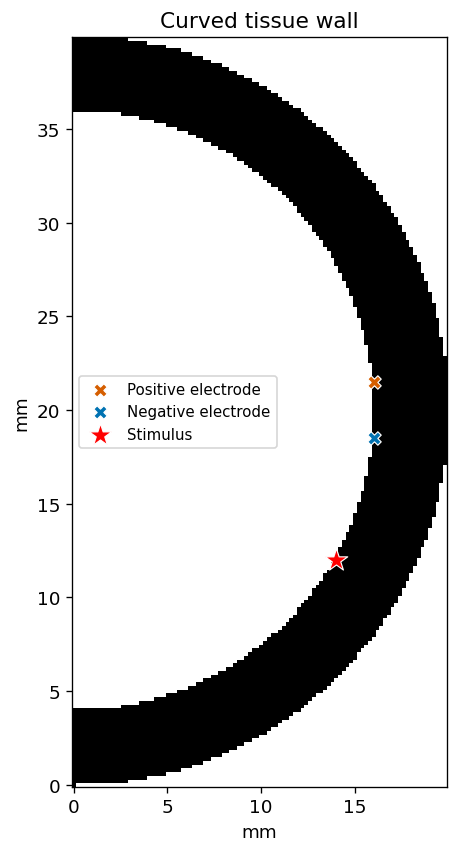

In [1]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from scipy import ndimage, spatial
import finitewave_tools.visualization as fwv

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 13})
negative_color = "#0072B2"
positive_color = "#D55E00"

# Coordinates used for geometry and electrode selection remain grid indices.
grid_size = 200
dr = 0.2
slice_index = grid_size // 2
inner_radius = grid_size // 2 - 20
outer_radius = grid_size // 2

distance_seed = np.ones((grid_size, grid_size // 2, grid_size), dtype=bool)
distance_seed[grid_size // 2, 0, :] = False
distance_to_axis = ndimage.distance_transform_edt(distance_seed)
tissue_mask = (distance_to_axis >= inner_radius) & (distance_to_axis <= outer_radius)

negative_electrode_center = np.array([grid_size // 2 - 7.5, inner_radius, slice_index])
positive_electrode_center = np.array([grid_size // 2 + 7.5, inner_radius, slice_index])

stimulus_center = np.array([[60, 70, slice_index]], dtype=np.float32)

# Pixel edges place each voxel center at its index multiplied by dr.
slice_extent = (
    -0.5 * dr, (tissue_mask.shape[1] - 0.5) * dr,
    -0.5 * dr, (tissue_mask.shape[0] - 0.5) * dr,
)


fig, ax = plt.subplots(figsize=(5.5, 7), layout="constrained")
ax.imshow(tissue_mask[..., slice_index], cmap="Greys", vmin=0, vmax=1,
          origin="lower", extent=slice_extent, interpolation="nearest")

ax.scatter(positive_electrode_center[1] * dr, positive_electrode_center[0] * dr,
           c=positive_color, s=65, marker="X", edgecolors="white",
           linewidths=0.7, label="Positive electrode", zorder=3)
ax.scatter(negative_electrode_center[1] * dr, negative_electrode_center[0] * dr,
           c=negative_color, s=65, marker="X", edgecolors="white",
           linewidths=0.7, label="Negative electrode", zorder=3)
ax.scatter(stimulus_center[0, 1] * dr, stimulus_center[0, 0] * dr,
           c="red", s=200, marker="*", edgecolors="white",
           linewidths=0.7, label="Stimulus", zorder=3)
ax.set(title="Curved tissue wall", xlabel="mm", ylabel="mm")
ax.set_aspect("equal")
ax.legend(loc="center left", fontsize=9)
plt.show()


## 2. Electrode patches

Each electrode occupies a small patch on the tissue surface. The two patches are disjoint and define where the negative and positive weighting potentials are prescribed.


In [2]:
def extract_boundary_voxels(mask):
    """Return all exposed tissue voxels, including inner walls and end faces."""
    return mask & ~ndimage.binary_erosion(mask)


def select_points_within_radius(center, candidate_coordinates, radius):
    tree = spatial.KDTree(candidate_coordinates)
    point_indices = tree.query_ball_point(center, radius)
    return candidate_coordinates[point_indices]


boundary_mask = extract_boundary_voxels(tissue_mask)
boundary_coordinates = np.argwhere(boundary_mask)
electrode_radius = 3
negative_electrode_coordinates = select_points_within_radius(
    negative_electrode_center, boundary_coordinates, electrode_radius,
)
positive_electrode_coordinates = select_points_within_radius(
    positive_electrode_center, boundary_coordinates, electrode_radius,
)
if not len(negative_electrode_coordinates) or not len(positive_electrode_coordinates):
    raise ValueError("Both electrodes must contain at least one boundary voxel.")

electrode_labels = np.zeros(tissue_mask.shape, dtype=np.int8)
electrode_labels[tuple(negative_electrode_coordinates.T)] = -1
if np.any(electrode_labels[tuple(positive_electrode_coordinates.T)] == -1):
    raise ValueError("Positive and negative electrode patches must be disjoint.")
electrode_labels[tuple(positive_electrode_coordinates.T)] = 1

negative_electrode_indices = np.flatnonzero(electrode_labels[tissue_mask] == -1)
positive_electrode_indices = np.flatnonzero(electrode_labels[tissue_mask] == 1)


## 3. Geometry and electrode placement

The gray surface shows the tissue, and the colored patches show the recording contacts on the curved wall.


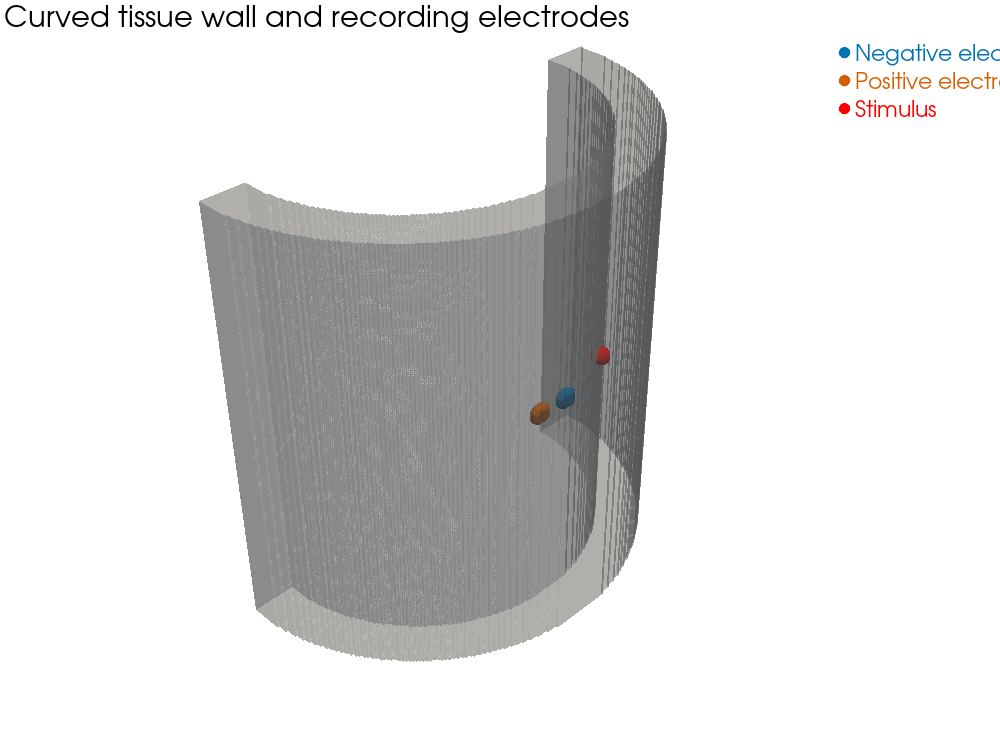

In [3]:
tissue_surface = fwv.PyVistaMeshGrid.from_mesh(
    tissue_mask, dr=dr, as_surface=True,
)
tissue_coordinates = np.argwhere(tissue_mask).astype(np.float32) * dr

pv.set_jupyter_backend("static")
geometry_plotter = pv.Plotter(window_size=(1000, 750))
geometry_plotter.set_background("white")
geometry_plotter.add_text("Curved tissue wall and recording electrodes", font_size=16, color="black")
geometry_plotter.add_mesh(tissue_surface, color="lightgray", opacity=0.45)
geometry_plotter.add_points(
    tissue_coordinates[negative_electrode_indices], color=negative_color,
    point_size=12, render_points_as_spheres=True, label="Negative electrode",
)
geometry_plotter.add_points(
    tissue_coordinates[positive_electrode_indices], color=positive_color,
    point_size=12, render_points_as_spheres=True, label="Positive electrode",
)
geometry_plotter.add_points(
    stimulus_center * dr, color="red", point_size=20, render_points_as_spheres=True,
    label="Stimulus",
)
geometry_plotter.add_legend(bcolor="white", face="circle", size=(0.25, 0.12))
geometry_plotter.camera_position = "iso"
geometry_plotter.show()


## 4. Stationary weighting problem

The weighting potential satisfies

$$
\nabla\cdot(D\nabla\psi)=0
$$

inside the conducting tissue, with fixed potentials on the electrode patches and zero normal flux elsewhere:

$$
\mathbf{n}\cdot D\nabla\psi=0.
$$

Here $D$ is the isotropic coefficient and $\mathbf{n}$ is the outward unit normal. For a homogeneous domain with fixed electrode potentials, multiplying $D$ by a positive constant leaves $\psi$ unchanged but changes the associated flux.

For intracellular and extracellular diffusion coefficients $D_i$ and $D_e$, the stationary problem uses $D=D_i+D_e$. The corresponding monodomain coefficient is

$$
D_m=\frac{D_iD_e}{D_i+D_e}.
$$


In [4]:
import finitewave as fw

intracellular_diffusion = 0.3
extracellular_diffusion = 0.3
monodomain_diffusion = (
    intracellular_diffusion * extracellular_diffusion
    / (intracellular_diffusion + extracellular_diffusion)
)

lead_field_tissue = fw.CardiacTissue(tissue_mask.shape, dr=dr)
lead_field_tissue.mesh = tissue_mask.astype(np.uint8)
lead_field_tissue.conductivity = intracellular_diffusion + extracellular_diffusion

lead_field_discretization = fw.FiniteDifferenceDiscretization()
lead_field_discretization.diffusion = fw.IsotropicDiffusion()
spatial_matrix, mass_matrix = lead_field_discretization.compute_weights(lead_field_tissue)


## 5. Weighting potential and electrogram weights

For electrode patches containing $N_-$ and $N_+$ nodes, the prescribed potentials are

$$
\psi|_{E_-}=-1/N_-,\qquad \psi|_{E_+}=+1/N_+.
$$

These values prescribe potentials, not injected currents. Division by patch size does not enforce unit total current. Physically calibrated amplitudes require consistent electrode-current normalization, source units, and spatial integration weights.

With prescribed nodes $B$, free nodes $F$, and spatial matrix $K$, the stationary equations reduce to

$$
K_{FF}\psi_F=-K_{FB}\psi_B.
$$

On a uniform three-dimensional grid with spacing $\Delta x$, the electrogram weights are

$$
w_j=\psi_j\,\Delta x^3\frac{D_i}{D_m},
\qquad D_m=\frac{D_iD_e}{D_i+D_e}.
$$

The factor $\Delta x^3$ accounts for voxel volume. This scaling does not replace electrode-current normalization, and $D_m$ must be consistent with the coefficient governing propagation for quantitative interpretation.


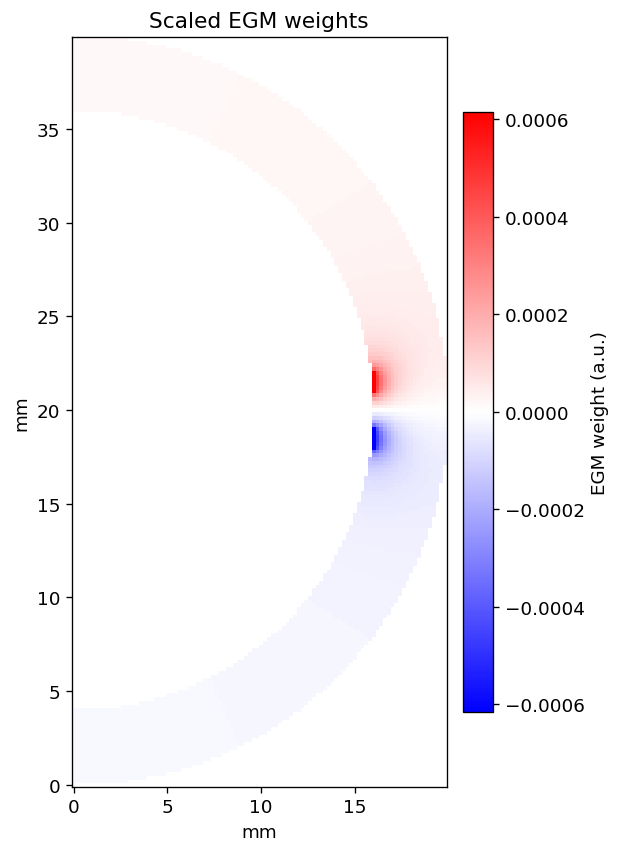

In [5]:
from finitewave_tools.linalg.linalg import make_system, linear_solver

electrode_boundary_conditions = [
    (negative_electrode_indices, -1 / len(negative_electrode_indices)),
    (positive_electrode_indices, 1 / len(positive_electrode_indices)),
]
reduced_matrix, reduced_rhs, boundary_potential, free_node_indices = make_system(
    spatial_matrix, dirichlet_conditions=electrode_boundary_conditions,
)

weighting_potential = boundary_potential.copy()
weighting_potential[free_node_indices] = linear_solver(
    reduced_matrix, reduced_rhs, x0=boundary_potential[free_node_indices],
)
# Preserve the volume and diffusion-ratio scaling separately from the solve.
egm_weight_scale = dr**3 * intracellular_diffusion / monodomain_diffusion
egm_weights = weighting_potential * egm_weight_scale

egm_weight_grid = np.full(tissue_mask.shape, np.nan, dtype=np.float32)
egm_weight_grid[tissue_mask] = egm_weights
weight_slice = np.ma.masked_invalid(egm_weight_grid[..., slice_index])
weight_limit = float(np.max(np.abs(egm_weights)))

fig, ax = plt.subplots(figsize=(6, 7), layout="constrained")
weight_image = ax.imshow(
    weight_slice, cmap="bwr", vmin=-weight_limit, vmax=weight_limit,
    origin="lower", extent=slice_extent, interpolation="nearest",
)
ax.set(title="Scaled EGM weights", xlabel="mm", ylabel="mm")
fig.colorbar(weight_image, ax=ax, shrink=0.8, pad=0.03, label="EGM weight (a.u.)")
plt.show()


## 6. Cardiac excitation and the EGM

A brief stimulus initiates an excitation wave described by the Luo–Rudy 1991 ventricular action-potential model. The stimulus initiates propagation, while the recording electrodes determine the spatial sensitivity of the bipolar lead.

Let $u_j^n$ be the transmembrane voltage at tissue node $j$ and time $t_n$, and let $r_j^n$ be the reaction and stimulus contribution to its time derivative. A discrete source estimate is

$$
s_j^n=\frac{u_j^{n+1}-u_j^n}{\Delta t}-r_j^n.
$$

The EGM is the weighted sum of these sources:

$$
\mathrm{EGM}^n=\sum_{j\in\mathrm{tissue}}w_j s_j^n.
$$

The voltage slice shows the propagating excitation through its transmembrane voltage distribution.


Running LuoRudy91 on (200, 100, 200) Grid: 100%|██████████| 2999/2999 [00:16<00:00, 183.05it/s]
/Users/arstanbekokenov/Projects/Finitewave/finitewave/simulation/model/cardiac_model.py:313: UserWarning: The number of tissue points is much smaller than the total mesh size. To reduce memory usage, consider using a ``output`` method that returns only the tissue points instead of the full mesh.
  warn(


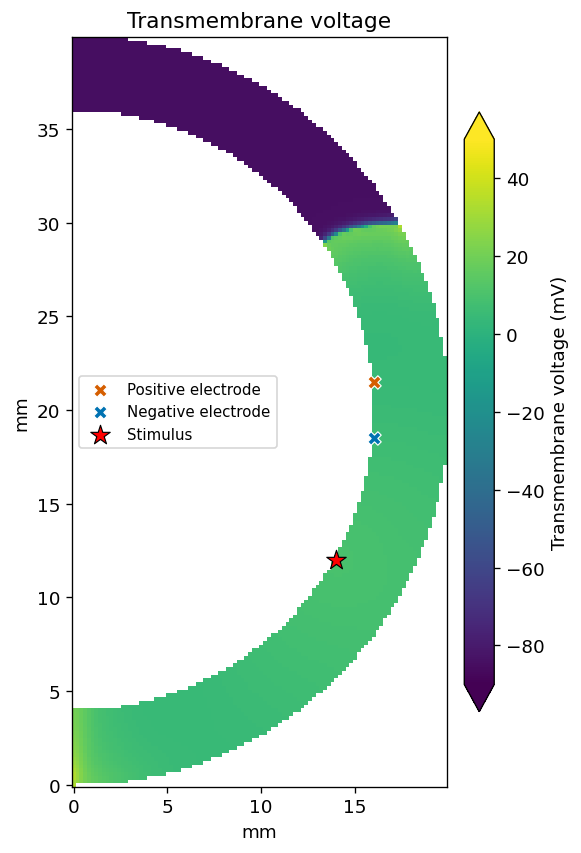

In [6]:
stimulus_center = np.array([[60, 70, slice_index]], dtype=np.float32)
stimulus_start = 0.0
stimulus_duration = 1.0

simulation_tissue = fw.CardiacTissue(tissue_mask.shape, dr=dr)
simulation_tissue.mesh = tissue_mask.astype(np.uint8)

egm_tracker = fw.EGMTracker(lead_fields=egm_weights)

simulation = fw.CardiacSimulation(dt=0.01, t_max=30, backend="jax")
simulation.cardiac_tissue = simulation_tissue
simulation.cardiac_model = fw.LuoRudy91()
simulation.stim_sequence = fw.StimSequence()
simulation.stim_sequence.add_stim(
    fw.StimCurrentElectrodes(
        time=stimulus_start, curr_value=100, duration=stimulus_duration,
        coords=stimulus_center, size=10,
    )
)
simulation.tracker_sequence = fw.TrackerSequence()
simulation.tracker_sequence.add_tracker(egm_tracker)

simulation.run()

transmembrane_voltage = simulation.cardiac_model.u
voltage_slice = np.ma.masked_where(
    ~tissue_mask[..., slice_index], transmembrane_voltage[..., slice_index],
)
fig, ax = plt.subplots(figsize=(6, 7), layout="constrained")
voltage_image = ax.imshow(
    voltage_slice, cmap="viridis", vmin=-90, vmax=50,
    origin="lower", extent=slice_extent, interpolation="nearest",
)

ax.set(title="Transmembrane voltage", xlabel="mm", ylabel="mm")
ax.scatter(positive_electrode_center[1] * dr, positive_electrode_center[0] * dr,
           c=positive_color, s=65, marker="X", edgecolors="white",
           linewidths=0.7, label="Positive electrode", zorder=3)
ax.scatter(negative_electrode_center[1] * dr, negative_electrode_center[0] * dr,
           c=negative_color, s=65, marker="X", edgecolors="white",
           linewidths=0.7, label="Negative electrode", zorder=3)
ax.scatter(stimulus_center[0, 1] * dr, stimulus_center[0, 0] * dr,
           marker="*", s=150, c="red", edgecolors="black",
           linewidths=0.7, label="Stimulus", zorder=4)

ax.legend(loc="center left", fontsize=9)
fig.colorbar(voltage_image, ax=ax, shrink=0.8, pad=0.03,
             label="Transmembrane voltage (mV)", extend="both")
plt.show()


## 7. Bipolar signal

The bipolar electrogram combines source contributions throughout the tissue. Its shape reflects how the evolving excitation interacts with the spatial weights. Under this normalization, amplitude is interpreted in arbitrary units.

Reversing the signs of the weights reverses signal polarity. Electrode positions, contact size, and propagation direction can change both amplitude and morphology; a deflection does not necessarily identify activation at a single location.


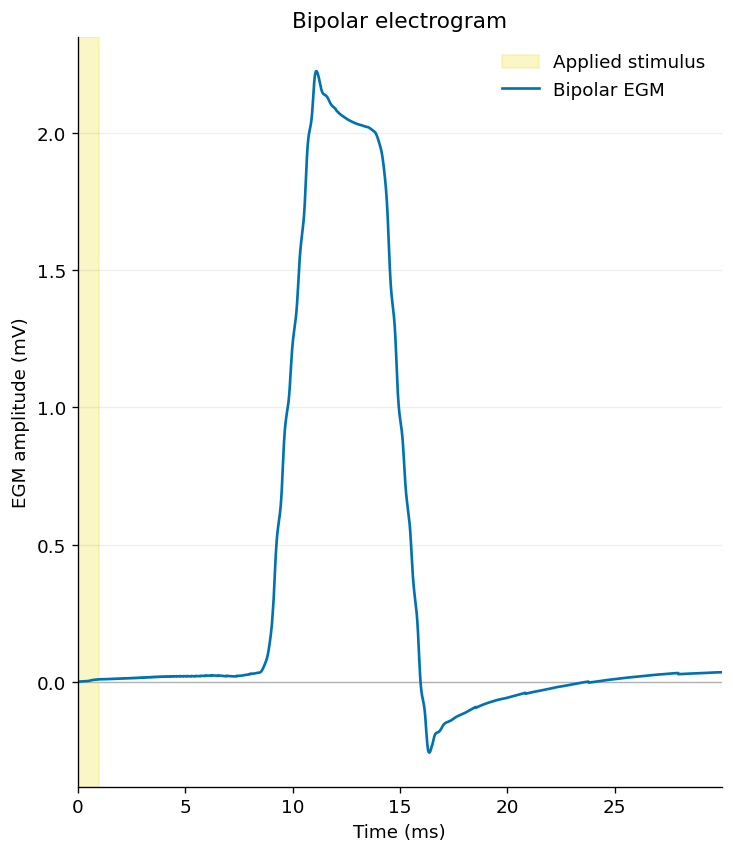

In [7]:
sample_times = egm_tracker.tracking_times
bipolar_egm = egm_tracker.output

fig, ax = plt.subplots(figsize=(6, 7), layout="constrained")
ax.axhline(0, color="0.7", linewidth=0.8, zorder=0)
ax.axvspan(stimulus_start, stimulus_start + stimulus_duration,
           color="#F0E442", alpha=0.3, label="Applied stimulus")
ax.plot(sample_times, bipolar_egm, color=negative_color, linewidth=1.6, label="Bipolar EGM")
ax.set(title="Bipolar electrogram", xlabel="Time (ms)", ylabel="EGM amplitude (mV)",
       xlim=(sample_times[0], sample_times[-1]))
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="best", frameon=False)
plt.show()


## References

1. Malmivuo, J., and Plonsey, R. (1995). *Bioelectromagnetism: Principles and Applications of Bioelectric and Biomagnetic Fields*. Oxford University Press. [Chapter 11, especially Section 11.6: lead fields and reciprocity](https://bem.fi/book/11/11.htm). Background on scalar reciprocal potentials, vector lead fields, and unit-current normalization.
2. Potse, M. (2018). *Scalable and Accurate ECG Simulation for Reaction-Diffusion Models of the Human Heart*. Frontiers in Physiology, **9**, 370. [doi:10.3389/fphys.2018.00370](https://doi.org/10.3389/fphys.2018.00370). Application of lead-field methods to efficient cardiac signal computation; the present simplified boundary conditions are not a reproduction of its full model.
3. Luo, C. H., and Rudy, Y. (1991). *A model of the ventricular cardiac action potential. Depolarization, repolarization, and their interaction*. Circulation Research, **68**(6), 1501–1526. [doi:10.1161/01.RES.68.6.1501](https://doi.org/10.1161/01.RES.68.6.1501). Source of the ventricular action-potential model.